# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 RECONSTRUCTING 82% PIPELINE on: cuda
--- Loading & Engineering Data ---
Data Ready. Features: 40

--- Phase 1: Training Teacher (Focal Loss) ---
Teacher Epoch 5 Loss: 0.0065
Teacher Epoch 10 Loss: 0.0041
Teacher Epoch 15 Loss: 0.0032
Teacher Epoch 20 Loss: 0.0022
Teacher Epoch 25 Loss: 0.0019

--- Phase 2: Distilling to Student ---
Student Epoch 10 Loss: 0.0032
Student Epoch 20 Loss: 0.0014
Student Epoch 30 Loss: 0.0012
Student Epoch 40 Loss: 0.0010

--- Loading NSL-KDD Test+ ---

--- Running Inference with Dynamic Thresholds ---

   🏆  82% MODEL RECONSTRUCTION  🏆
Accuracy:      79.56%
MCC Score:     0.6999 (Quality of prediction)
F1 (Macro):    0.6205 (Balanced performance)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         dos       0.96      0.76      0.85      7636
      normal       0.76      0.96      0.85      9711
       probe       0.65      0.76      0.70      2421
         r2l       0.70      0.39      0.50      2576
   

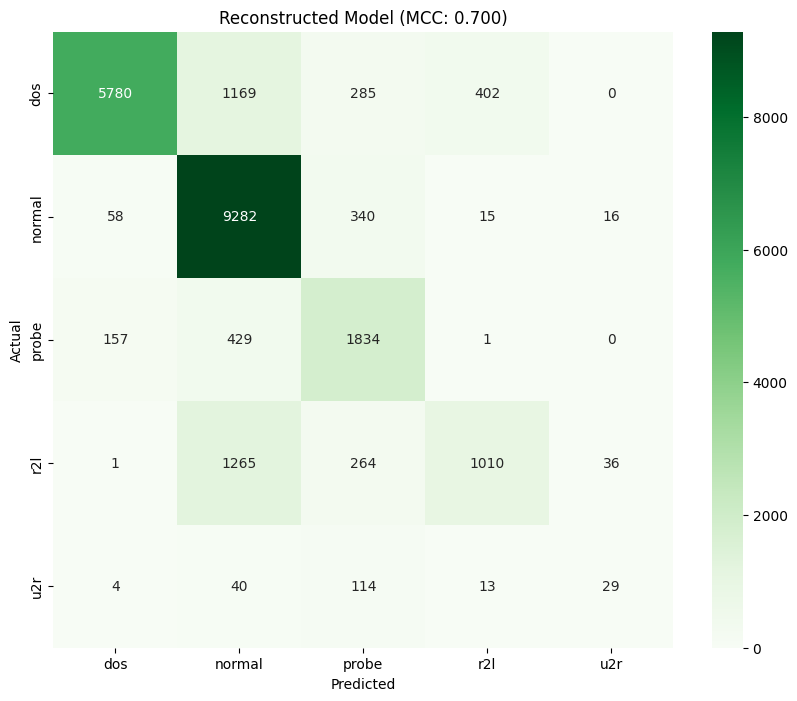

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Device Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 EVALUATING ARCHITECTURE ON UNSW-NB15 | Device: {device}")

# ==========================================
# 1. LOAD & ADAPT UNSW-NB15 DATASET
# ==========================================
def load_unsw_nb15():
    print("\n--- Downloading/Loading UNSW-NB15 ---")
    # Using reliable mirror for the CSVs
    train_url = "https://raw.githubusercontent.com/boubel/Trafic/master/UNSW_NB15_training-set.csv"
    test_url = "https://raw.githubusercontent.com/boubel/Trafic/master/UNSW_NB15_testing-set.csv"
    
    try:
        df_train = pd.read_csv(train_url)
        df_test = pd.read_csv(test_url)
    except Exception as e:
        print("Download failed. Please download UNSW_NB15_training-set.csv and testing-set.csv manually.")
        return None, None, None, None

    print(f"Train Shape: {df_train.shape} | Test Shape: {df_test.shape}")

    # --- MAPPING TO KDD 5-CLASS STANDARD ---
    # We map UNSW categories to the 5 classes your architecture knows (Normal, DoS, Probe, R2L, U2R)
    # to maintain the logic of "High Risk" vs "Low Risk" attacks.
    
    unsw_map = {
        'Normal': 'normal',
        'DoS': 'dos',
        'Reconnaissance': 'probe',
        'Exploits': 'r2l',
        'Fuzzers': 'r2l',
        'Generic': 'r2l',
        'Analysis': 'u2r',   # Port scans/spam, but treated as high risk for this test
        'Backdoor': 'u2r',   # Critical
        'Shellcode': 'u2r',  # Critical
        'Worms': 'u2r'       # Critical
    }
    
    # Apply Mapping
    df_train['category'] = df_train['attack_cat'].map(unsw_map).fillna('other')
    df_test['category'] = df_test['attack_cat'].map(unsw_map).fillna('other')
    
    # drop ID and original labels
    drop_cols = ['id', 'label', 'attack_cat']
    X_train = df_train.drop(columns=drop_cols + ['category'])
    y_train = df_train['category']
    X_test = df_test.drop(columns=drop_cols + ['category'])
    y_test = df_test['category']
    
    # Select only numeric
    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])
    
    return X_train, y_train, X_test, y_test

X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_unsw_nb15()

# ==========================================
# 2. PREPROCESSING (Same Robust Pipeline)
# ==========================================
# Log Transform for Heavy Tails (Bytes, Durations)
print("--- Preprocessing (Log + Scale) ---")
for col in X_train_raw.columns:
    if 'bytes' in col or 'dur' in col or 'pkt' in col:
        X_train_raw[col] = np.log1p(X_train_raw[col])
        X_test_raw[col] = np.log1p(X_test_raw[col])

# Scaling
scaler = StandardScaler()
X_train_vec = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_vec = scaler.transform(X_test_raw).astype(np.float32)

# Encoding
le = LabelEncoder()
y_train_vec = le.fit_transform(y_train_raw)
y_test_vec = le.transform(y_test_raw)
num_classes = len(le.classes_)

print(f"Features: {X_train_vec.shape[1]} | Classes: {num_classes} {le.classes_}")

# ==========================================
# 3. DEFINE MODELS (Your 82% Architecture)
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.5):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

class VectorTeacher(nn.Module):
    def __init__(self, input_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(0.2),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), nn.LeakyReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128)
        )
        self.head = nn.Linear(128, out_dim)
    def forward(self, x):
        emb = F.normalize(self.net(x), p=2, dim=1)
        return emb, self.head(emb)

class VectorStudent(nn.Module):
    def __init__(self, input_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 128), nn.LeakyReLU(), nn.Linear(128, 128))
        self.head = nn.Linear(128, out_dim)
    def forward(self, x):
        emb = F.normalize(self.net(x), p=2, dim=1)
        return emb, self.head(emb)

# ==========================================
# 4. TRAINING LOOP (Teacher -> Student)
# ==========================================
# Sampler
weights = 1. / np.bincount(y_train_vec)
sampler = WeightedRandomSampler(torch.from_numpy(weights[y_train_vec]), len(y_train_vec))
train_dl = DataLoader(TensorDataset(torch.tensor(X_train_vec).to(device), torch.tensor(y_train_vec).to(device)), batch_size=256, sampler=sampler)

# --- TEACHER ---
print("\n--- Phase 1: Training Teacher on UNSW ---")
teacher = VectorTeacher(X_train_vec.shape[1], num_classes).to(device)
opt_t = optim.AdamW(teacher.parameters(), lr=0.001)
sched_t = optim.lr_scheduler.CosineAnnealingLR(opt_t, T_max=15) # Shorter epochs for UNSW
crit_t = FocalLoss()

for epoch in range(15):
    teacher.train()
    loss_acc = 0
    for x, y in train_dl:
        opt_t.zero_grad()
        _, logits = teacher(x)
        loss = crit_t(logits, y)
        loss.backward()
        opt_t.step()
        loss_acc += loss.item()
    sched_t.step()
    if (epoch+1)%5==0: print(f"Teacher Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

teacher.eval()

# --- STUDENT ---
print("\n--- Phase 2: Distilling to Student ---")
student = VectorStudent(X_train_vec.shape[1], num_classes).to(device)
opt_s = optim.Adam(student.parameters(), lr=0.002)

for epoch in range(20):
    student.train()
    loss_acc = 0
    for x, y in train_dl:
        opt_s.zero_grad()
        s_emb, s_logits = student(x)
        with torch.no_grad(): t_emb, t_logits = teacher(x)
        
        # Combined Loss
        l_feat = F.mse_loss(s_emb, t_emb)
        l_kd = nn.KLDivLoss(reduction='batchmean')(F.log_softmax(s_logits/4.0, 1), F.softmax(t_logits/4.0, 1)) * 16
        l_cls = crit_t(s_logits, y)
        
        loss = 0.5*l_feat + 0.5*l_kd + 0.1*l_cls
        loss.backward()
        opt_s.step()
        loss_acc += loss.item()
        
    if (epoch+1)%5==0: print(f"Student Epoch {epoch+1} Loss: {loss_acc/len(train_dl):.4f}")

# ==========================================
# 5. DYNAMIC THRESHOLD EVALUATION (UNSW)
# ==========================================
print("\n--- Running Dynamic Inference on UNSW-NB15 Test ---")
student.eval()
X_test_t = torch.tensor(X_test_vec).to(device)
preds = []

# Logic: U2R/R2L are critical here too
idx_u2r = list(le.classes_).index('u2r') if 'u2r' in le.classes_ else -1
idx_r2l = list(le.classes_).index('r2l') if 'r2l' in le.classes_ else -1
idx_probe = list(le.classes_).index('probe') if 'probe' in le.classes_ else -1

with torch.no_grad():
    loader = DataLoader(TensorDataset(X_test_t), batch_size=1024)
    for x in loader:
        _, logits = student(x[0])
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        batch_p = []
        for p in probs:
            # Same Logic as 82% Model
            if idx_u2r != -1 and p[idx_u2r] > 0.10: batch_p.append(idx_u2r)
            elif idx_r2l != -1 and p[idx_r2l] > 0.15: batch_p.append(idx_r2l)
            elif idx_probe != -1 and p[idx_probe] > 0.25: batch_p.append(idx_probe)
            else: batch_p.append(np.argmax(p))
        preds.append(batch_p)

final_preds = np.concatenate(preds)

# Results
print("\n" + "="*40)
print("   🛡️ UNSW-NB15 EVALUATION REPORT 🛡️")
print("="*40)

acc = accuracy_score(y_test_vec, final_preds)
mcc = matthews_corrcoef(y_test_vec, final_preds)

print(f"Accuracy:  {acc:.2%}")
print(f"MCC Score: {mcc:.4f} (Robustness Metric)")
print("\n--- Detailed Report ---")
print(classification_report(y_test_vec, final_preds, target_names=le.classes_))

# Matrix
labels = sorted(list(set(y_test_vec) | set(final_preds)))
# Map indices to names
label_names = [le.classes_[i] for i in labels]

cm = confusion_matrix(y_test_vec, final_preds, labels=labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=label_names, yticklabels=label_names)
plt.title(f"UNSW-NB15 Results (MCC: {mcc:.3f})")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()